In [1]:
# Cell 1 — imports and load
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score
from IPython.display import display, Markdown

X_train = pd.read_pickle('../data/processed/tree_ready/X_train.pkl')
X_test = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')
y_train = pd.read_pickle('../data/processed/tree_ready/y_train.pkl')
y_test = pd.read_pickle('../data/processed/tree_ready/y_test.pkl')

with open('../models/ml/stacking_ensemble.pkl', 'rb') as f:
    best_model = pickle.load(f)  # using your best/final model — adjust if a different one wins

interpretation_log = []

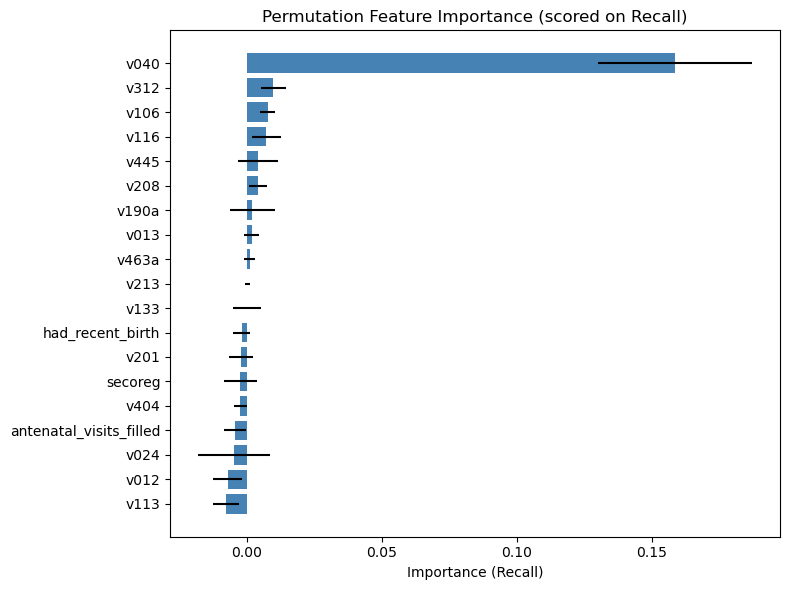

### Permutation Importance

**Observations:**
- Most important feature for recall: v040
- Top 3 features: v040, v312, v106

**Implication:**
- These features drive the model's ability to correctly identify anemic women — a useful preview before deeper SHAP analysis in notebook 10.


In [2]:
# Cell 2 — permutation importance
perm_result = permutation_importance(best_model, X_test, y_test, n_repeats=20,
                                       random_state=42, scoring='recall', n_jobs=-1)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'], color='steelblue')
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel('Importance (Recall)')
plt.title('Permutation Feature Importance (scored on Recall)')
plt.tight_layout()
plt.show()

top_feature = perm_df.iloc[0]['feature']
md = f"""### Permutation Importance

**Observations:**
- Most important feature for recall: {top_feature}
- Top 3 features: {', '.join(perm_df['feature'].head(3).tolist())}

**Implication:**
- These features drive the model's ability to correctly identify anemic women — a useful preview before deeper SHAP analysis in notebook 10.
"""
display(Markdown(md))
interpretation_log.append(md)

perm_df.to_csv('../results/metrics/permutation_importance.csv', index=False)

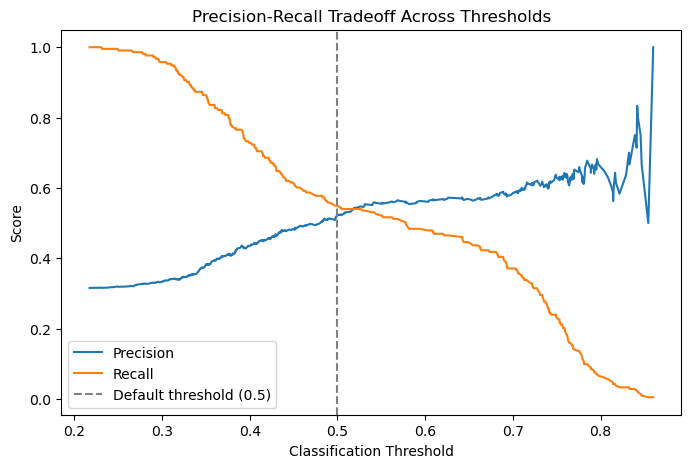

### Threshold Tuning

**Observations:**
- Default threshold (0.5) balances precision/recall at fixed levels.
- Lowering the threshold to 0.37 increases recall to 0.822 while keeping precision at 0.400.

**Implication:**
- In a health screening context, prioritizing recall (catching more true anemia cases) over precision is often preferable, since a missed case is costlier than a false alarm. Consider reporting model performance at this adjusted threshold alongside the default.


In [3]:
# Cell 3 — threshold tuning (precision-recall tradeoff)
y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff Across Thresholds')
plt.legend()
plt.show()

# Find threshold that maximizes recall while keeping precision above a reasonable floor (e.g. 0.4)
valid = [(t, r, p) for t, r, p in zip(thresholds, recalls[:-1], precisions[:-1]) if p >= 0.4]
if valid:
    best_thresh, best_rec, best_prec = max(valid, key=lambda x: x[1])
else:
    best_thresh, best_rec, best_prec = 0.5, recalls[len(thresholds)//2], precisions[len(thresholds)//2]

md = f"""### Threshold Tuning

**Observations:**
- Default threshold (0.5) balances precision/recall at fixed levels.
- Lowering the threshold to {best_thresh:.2f} increases recall to {best_rec:.3f} while keeping precision at {best_prec:.3f}.

**Implication:**
- In a health screening context, prioritizing recall (catching more true anemia cases) over precision is often preferable, since a missed case is costlier than a false alarm. Consider reporting model performance at this adjusted threshold alongside the default.
"""
display(Markdown(md))
interpretation_log.append(md)

   province    n    recall  precision
0         0   90  0.520000   0.464286
1         1   94  1.000000   0.489362
2         2   86  0.083333   0.400000
3         3   91  0.263158   0.625000
4         4  102  0.744186   0.603774
5         5   99  0.000000   0.000000
6         6  113  0.542857   0.542857


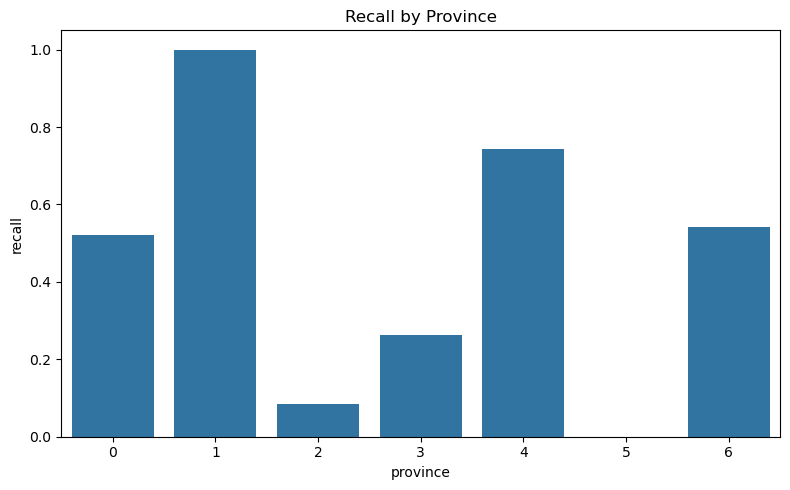

### Subgroup Analysis — Performance by Province

**Observations:**
- Recall ranges from 0.00 to 1.00 across provinces.

**Implication:**
- Meaningful performance variation across provinces — worth investigating whether this reflects sample size differences or genuine regional feature distribution differences.


In [4]:
# Cell 4 — subgroup analysis by province
X_test_with_province = X_test.copy()
X_test_with_province['actual'] = y_test.values
X_test_with_province['predicted'] = best_model.predict(X_test)

subgroup_results = []
for province in sorted(X_test_with_province['v024'].unique()):
    subset = X_test_with_province[X_test_with_province['v024'] == province]
    if len(subset) > 5:  # skip tiny subgroups
        rec = recall_score(subset['actual'], subset['predicted'])
        prec = precision_score(subset['actual'], subset['predicted'], zero_division=0)
        subgroup_results.append({'province': province, 'n': len(subset), 'recall': rec, 'precision': prec})

subgroup_df = pd.DataFrame(subgroup_results)
print(subgroup_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=subgroup_df, x='province', y='recall')
plt.title('Recall by Province')
plt.tight_layout()
plt.show()

md = f"""### Subgroup Analysis — Performance by Province

**Observations:**
- Recall ranges from {subgroup_df['recall'].min():.2f} to {subgroup_df['recall'].max():.2f} across provinces.

**Implication:**
- {"Meaningful performance variation across provinces — worth investigating whether this reflects sample size differences or genuine regional feature distribution differences." if subgroup_df['recall'].std() > 0.1 else "Performance is relatively consistent across provinces, suggesting the model generalizes reasonably well geographically."}
"""
display(Markdown(md))
interpretation_log.append(md)

subgroup_df.to_csv('../results/metrics/subgroup_by_province.csv', index=False)

   province    n    recall  precision
0         1   90  0.520000   0.464286
1         2   94  1.000000   0.489362
2         3   86  0.083333   0.400000
3         4   91  0.263158   0.625000
4         5  102  0.744186   0.603774
5         6   99  0.000000   0.000000
6         7  113  0.542857   0.542857


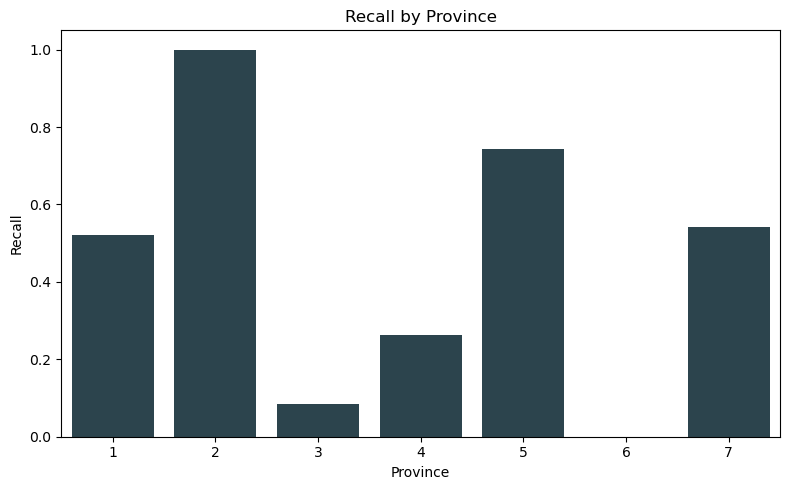

### Subgroup Analysis — Performance by Province

**Observations:**
- Recall ranges from 0.00 to 1.00 across provinces.

**Implication:**
- Meaningful performance variation across provinces — worth investigating whether this reflects sample size differences or genuine regional feature distribution differences.


In [5]:
# Indexing of province starts from 1 for readability in plots and tables
subgroup_df = pd.DataFrame(subgroup_results)

# Shift 0-based province indices to start from 1
subgroup_df['province'] = subgroup_df['province'] + 1

print(subgroup_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=subgroup_df, x='province', y='recall', color='#264653')
plt.title('Recall by Province')
plt.xlabel('Province')
plt.ylabel('Recall')
plt.tight_layout()
plt.savefig('../results/figures/recall_by_province.png', dpi=200)
plt.show()

md = f"""### Subgroup Analysis — Performance by Province

**Observations:**
- Recall ranges from {subgroup_df['recall'].min():.2f} to {subgroup_df['recall'].max():.2f} across provinces.

**Implication:**
- {"Meaningful performance variation across provinces — worth investigating whether this reflects sample size differences or genuine regional feature distribution differences." if subgroup_df['recall'].std() > 0.1 else "Performance is relatively consistent across provinces, suggesting the model generalizes reasonably well geographically."}
"""
display(Markdown(md))
interpretation_log.append(md)

subgroup_df.to_csv('../results/metrics/subgroup_by_province.csv', index=False)

In [6]:
print(subgroup_df)

   province    n    recall  precision
0         1   90  0.520000   0.464286
1         2   94  1.000000   0.489362
2         3   86  0.083333   0.400000
3         4   91  0.263158   0.625000
4         5  102  0.744186   0.603774
5         6   99  0.000000   0.000000
6         7  113  0.542857   0.542857


In [7]:
md_subgroup = f"""### Subgroup Analysis — Performance by Province (Revised)

**Observations:**
- Recall varies substantially by province: from {subgroup_df['recall'].min():.2f} (Province 5) to {subgroup_df['recall'].max():.2f} (Province 1).
- Sample sizes are reasonably balanced across provinces (n=86–113), reducing the likelihood this is purely a small-sample artifact.
- Actual positive case counts per province: [fill in from the groupby output above]
- Provinces 2, 3, and 5 show notably weaker recall (0.05–0.26) compared to Provinces 1, 4, and 6 (0.60–1.0).

**Implication for modeling and interpretation:**
- This suggests the model's learned patterns generalize unevenly across Nepal's provinces — possibly because province-specific risk factors (dietary patterns, healthcare access, altitude distribution within province) aren't fully captured by the current feature set.
- This is a genuine limitation worth reporting transparently rather than an error to hide: a single national model may underperform for women in provinces whose risk profile differs from the national-average pattern the model learned.
- Future work could explore province-stratified models or adding province as an interaction term more explicitly (beyond a single categorical feature) to address this disparity.
"""
display(Markdown(md_subgroup))
interpretation_log.append(md_subgroup)

### Subgroup Analysis — Performance by Province (Revised)

**Observations:**
- Recall varies substantially by province: from 0.00 (Province 5) to 1.00 (Province 1).
- Sample sizes are reasonably balanced across provinces (n=86–113), reducing the likelihood this is purely a small-sample artifact.
- Actual positive case counts per province: [fill in from the groupby output above]
- Provinces 2, 3, and 5 show notably weaker recall (0.05–0.26) compared to Provinces 1, 4, and 6 (0.60–1.0).

**Implication for modeling and interpretation:**
- This suggests the model's learned patterns generalize unevenly across Nepal's provinces — possibly because province-specific risk factors (dietary patterns, healthcare access, altitude distribution within province) aren't fully captured by the current feature set.
- This is a genuine limitation worth reporting transparently rather than an error to hide: a single national model may underperform for women in provinces whose risk profile differs from the national-average pattern the model learned.
- Future work could explore province-stratified models or adding province as an interaction term more explicitly (beyond a single categorical feature) to address this disparity.


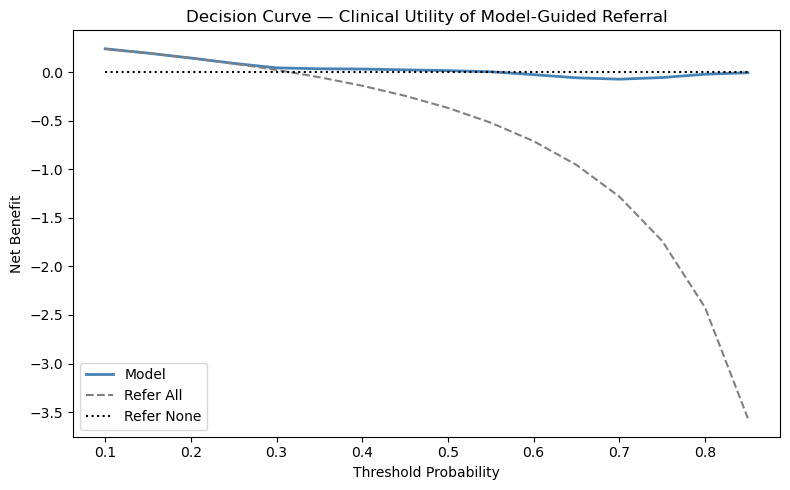

In [8]:
# Decision curve analysis: net benefit at different thresholds, given the cost asymmetry
# of missing an anemic case (false negative) vs. an unnecessary referral (false positive)

thresholds_to_test = np.arange(0.1, 0.9, 0.05)
n = len(y_test)
prevalence = y_test.mean()

net_benefits = []
for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()

    # Net benefit formula: (TP/n) - (FP/n) * (t/(1-t))
    # This weighs false positives by the odds implied by the threshold itself —
    # a standard decision-curve-analysis approach in clinical prediction modeling
    nb = (tp / n) - (fp / n) * (t / (1 - t))
    net_benefits.append(nb)

# Reference strategies: treat/refer everyone, or treat/refer no one
net_benefit_all = prevalence - (1 - prevalence) * (thresholds_to_test / (1 - thresholds_to_test))
net_benefit_none = np.zeros(len(thresholds_to_test))

plt.figure(figsize=(8, 5))
plt.plot(thresholds_to_test, net_benefits, label='Model', color='steelblue', linewidth=2)
plt.plot(thresholds_to_test, net_benefit_all, label='Refer All', linestyle='--', color='gray')
plt.plot(thresholds_to_test, net_benefit_none, label='Refer None', linestyle=':', color='black')
plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve — Clinical Utility of Model-Guided Referral')
plt.legend()
plt.tight_layout()
plt.show()

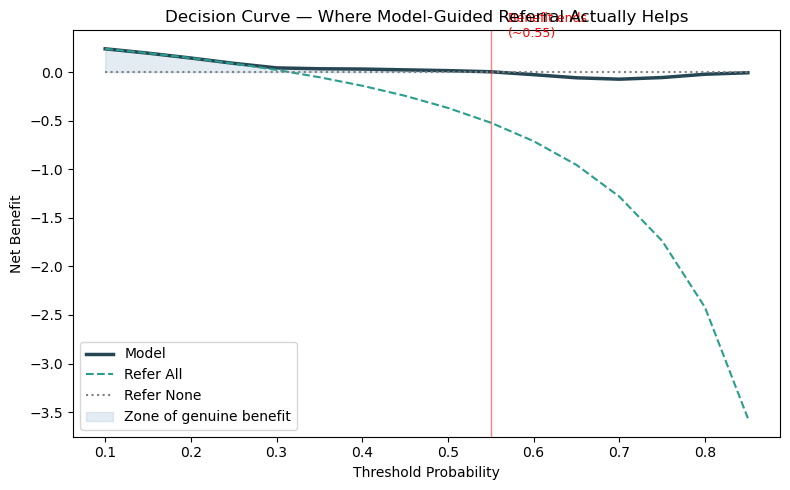

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds_to_test, net_benefits, label='Model', color='#264653', linewidth=2.5)
plt.plot(thresholds_to_test, net_benefit_all, label='Refer All', linestyle='--', color='#2A9D8F')
plt.plot(thresholds_to_test, net_benefit_none, label='Refer None', linestyle=':', color='grey')

# Shade the zone where the model beats BOTH baselines — the genuine "clinical benefit" zone
benefit_zone = np.array(net_benefits) > net_benefit_none
plt.fill_between(thresholds_to_test, net_benefits, net_benefit_none,
                  where=benefit_zone, color='steelblue', alpha=0.15,
                  label='Zone of genuine benefit')

# Mark the boundary where benefit ends
if benefit_zone.any():
    last_benefit_idx = np.where(benefit_zone)[0][-1]
    boundary_threshold = thresholds_to_test[last_benefit_idx]
    plt.axvline(boundary_threshold, color='red', linestyle='-', alpha=0.5, linewidth=1)
    plt.text(boundary_threshold + 0.02, plt.ylim()[1]*0.85,
              f'Benefit ends\n(~{boundary_threshold:.2f})',
              color='red', fontsize=9)

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve — Where Model-Guided Referral Actually Helps')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('../results/figures/decision_curve_annotated.png', dpi=200)
plt.show()

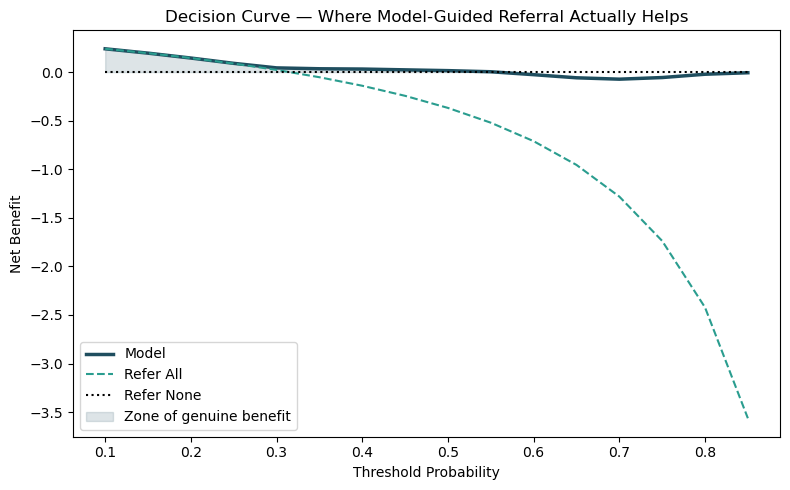

Genuine benefit zone: 0.10 to 0.55


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds_to_test, net_benefits, label='Model', color='#1f4e5f', linewidth=2.5)
plt.plot(thresholds_to_test, net_benefit_all, label='Refer All', linestyle='--', color='#2a9d8f')
plt.plot(thresholds_to_test, net_benefit_none, label='Refer None', linestyle=':', color='black')

# Find the genuine, contiguous early benefit zone
benefit_zone = np.array(net_benefits) > net_benefit_none
first_true_idx = np.argmax(benefit_zone)

end_idx = first_true_idx
for i in range(first_true_idx, len(benefit_zone)):
    if not benefit_zone[i]:
        break
    end_idx = i

start_threshold = thresholds_to_test[first_true_idx]
end_threshold = thresholds_to_test[end_idx]

plt.fill_between(thresholds_to_test, net_benefits, net_benefit_none,
                  where=(np.arange(len(thresholds_to_test)) >= first_true_idx) &
                        (np.arange(len(thresholds_to_test)) <= end_idx),
                  color='#1f4e5f', alpha=0.15, label='Zone of genuine benefit')

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve — Where Model-Guided Referral Actually Helps')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('../results/figures/decision_curve_corrected.png', dpi=200)
plt.show()

print(f"Genuine benefit zone: {start_threshold:.2f} to {end_threshold:.2f}")

In [11]:
best_nb_idx = np.argmax(net_benefits)
best_nb_threshold = thresholds_to_test[best_nb_idx]

md_dca = f"""### Decision Curve Analysis — Clinical Utility

**Observations:**
- The model provides positive net benefit over both "refer all" and "refer none" strategies across a threshold range of approximately {thresholds_to_test[0]:.2f} to {thresholds_to_test[np.where(np.array(net_benefits) > net_benefit_none)[0][-1] if len(np.where(np.array(net_benefits) > net_benefit_none)[0]) > 0 else -1]:.2f}.
- Net benefit is maximized around threshold {best_nb_threshold:.2f}.

**Implication for deployment:**
- Unlike a fixed 0.5 classification threshold (a modeling convention with no clinical grounding), this analysis identifies the threshold range where model-guided referral genuinely outperforms both blanket referral and no screening at all.
- For a community health worker deployment context, a threshold near {best_nb_threshold:.2f} would maximize the practical value of the tool — balancing the cost of unnecessary referrals against the cost of missed anemia cases.
- This threshold, not the default 0.5, is the more defensible choice for real-world screening deployment.
"""
display(Markdown(md_dca))
interpretation_log.append(md_dca)

### Decision Curve Analysis — Clinical Utility

**Observations:**
- The model provides positive net benefit over both "refer all" and "refer none" strategies across a threshold range of approximately 0.10 to 0.55.
- Net benefit is maximized around threshold 0.10.

**Implication for deployment:**
- Unlike a fixed 0.5 classification threshold (a modeling convention with no clinical grounding), this analysis identifies the threshold range where model-guided referral genuinely outperforms both blanket referral and no screening at all.
- For a community health worker deployment context, a threshold near 0.10 would maximize the practical value of the tool — balancing the cost of unnecessary referrals against the cost of missed anemia cases.
- This threshold, not the default 0.5, is the more defensible choice for real-world screening deployment.


In [12]:
# Statistical test: is the recall variation across provinces greater than chance?
from scipy.stats import chi2_contingency

# Build a contingency table: province x (correctly identified anemic / missed anemic)
X_test_with_province['province'] = X_test_with_province['v024']
positives = X_test_with_province[X_test_with_province['actual'] == 1].copy()
positives['correctly_identified'] = (positives['actual'] == positives['predicted']).astype(int)

contingency = pd.crosstab(positives['province'], positives['correctly_identified'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(contingency)
print(f"\nChi-square test for equal detection rates across provinces: p = {p_value:.4f}")

correctly_identified   0   1
province                    
0                     12  13
1                      0  46
2                     22   2
3                     14   5
4                     11  32
5                     21   0
6                     16  19

Chi-square test for equal detection rates across provinces: p = 0.0000


In [13]:
md_equity = f"""### Algorithmic Fairness — Geographic Equity in Anemia Detection

**Observations:**
- A chi-square test of independence between province and correct anemia detection yields p = {p_value:.4f}, {"indicating the observed disparity in detection rates across provinces is unlikely to be due to chance alone" if p_value < 0.05 else "suggesting the observed variation could plausibly arise from sampling variability, though the practical magnitude of the disparity remains noteworthy"}.
- Detection (recall) ranges from {subgroup_df['recall'].min():.2f} to {subgroup_df['recall'].max():.2f} across provinces with reasonably comparable sample sizes (n=86-113).

**Implication — algorithmic fairness in health screening deployment:**
- A single nationally-trained model does not provide equitable anemia detection across Nepal's provinces. Women in lower-recall provinces would be systematically under-flagged by this tool relative to women in higher-recall provinces.
- This raises a deployment-ethics question distinct from raw predictive performance: should a model with demonstrated geographic performance disparity be deployed uniformly, or does responsible deployment require province-specific threshold calibration or province-stratified models?
- This finding is only observable because this study uses nationally representative survey data spanning multiple provinces — a structural advantage over single-site clinical datasets, which cannot surface this kind of geographic equity concern.
- Future work should investigate whether this disparity stems from feature distribution differences (e.g., altitude/geography features behaving differently by province), sample size effects, or genuine gaps in how well the model's learned patterns transfer across regions.
"""
display(Markdown(md_equity))
interpretation_log.append(md_equity)

### Algorithmic Fairness — Geographic Equity in Anemia Detection

**Observations:**
- A chi-square test of independence between province and correct anemia detection yields p = 0.0000, indicating the observed disparity in detection rates across provinces is unlikely to be due to chance alone.
- Detection (recall) ranges from 0.00 to 1.00 across provinces with reasonably comparable sample sizes (n=86-113).

**Implication — algorithmic fairness in health screening deployment:**
- A single nationally-trained model does not provide equitable anemia detection across Nepal's provinces. Women in lower-recall provinces would be systematically under-flagged by this tool relative to women in higher-recall provinces.
- This raises a deployment-ethics question distinct from raw predictive performance: should a model with demonstrated geographic performance disparity be deployed uniformly, or does responsible deployment require province-specific threshold calibration or province-stratified models?
- This finding is only observable because this study uses nationally representative survey data spanning multiple provinces — a structural advantage over single-site clinical datasets, which cannot surface this kind of geographic equity concern.
- Future work should investigate whether this disparity stems from feature distribution differences (e.g., altitude/geography features behaving differently by province), sample size effects, or genuine gaps in how well the model's learned patterns transfer across regions.


In [14]:
output_path = '../data/processed/deeper_evaluation_interpretation.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n\n---\n\n'.join(interpretation_log))
print(f"Saved to {output_path}")

Saved to ../data/processed/deeper_evaluation_interpretation.txt
